# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Elias Hawkins & Davin Matias*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>

In [ ]:
# Your imports here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [ ]:

# MNIST Classification with CNN

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values (0, 255) -> (0-1)
X_train = X_train.astype('float32') / 255
x_test = X_test.astype('float32') / 255

# One-hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Your written answers for Part A:*

- Image size chosen and why: The image size of the dataset used above is 28x28 pixels.
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [ ]:
# Build your CNN model here
model = Sequential()

model.add(Conv2D(16, kernel_size=3, activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=2, strides=2))

model.add(Conv2D(32, kernel_size=3, activation="relu"))
model.add(MaxPooling2D(pool_size=2, strides=2))

model.add(Flatten())

model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

*Your architecture justification (one paragraph):* We used two convolution layers, two pooling layers, and a kernel size of 3 because the size of the images are only 28x28 pixels. As seen above the Dense classifier head shows the pixels being flattened into a vector size of 1. We used 10 units in the output Dense layer because the fashion_mnist dataset has 10 categories. We used softmax for the activation function because it turns raw outputs into class probabilities that sum up to 1 making it easy to deal with the 10 categories we have.



---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [ ]:
# Train your model here (save the result as `history`)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.8118 - loss: 0.5230 - val_accuracy: 0.8029 - val_loss: 60.6161
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.8692 - loss: 0.3625 - val_accuracy: 0.8089 - val_loss: 59.3336
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.8840 - loss: 0.3218 - val_accuracy: 0.7937 - val_loss: 65.8908
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.8931 - loss: 0.2965 - val_accuracy: 0.8086 - val_loss: 59.2236
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8982 - loss: 0.2780 - val_accuracy: 0.7788 - val_loss: 74.6216
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9036 - loss: 0.2649 - val_accuracy: 0.7980 - val_loss: 61.5811
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9089 - loss: 0.2511 - val_accuracy: 0.7895 - val_loss: 73.6770
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

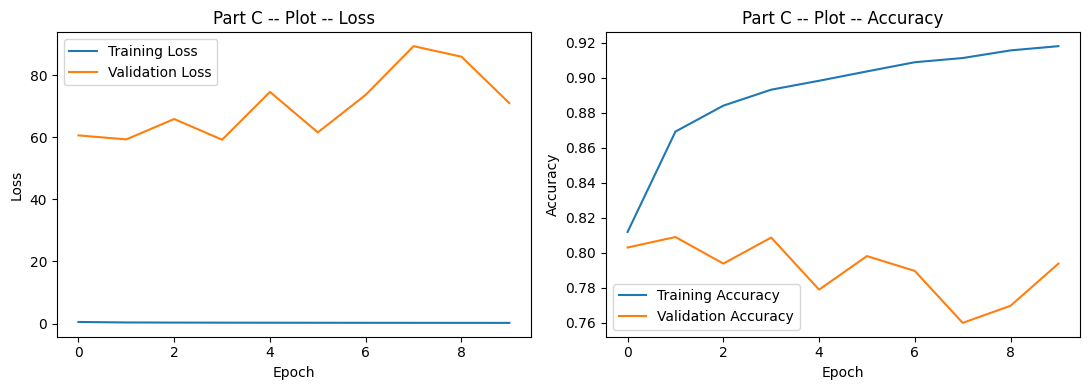

In [ ]:
# Plot training vs. validation loss and accuracy here
plot_history(history, "Part C -- Plot", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*

**The model is heavily overfitted. The training loss line staying at 0 means the model has memorized the dataset it was provided.**


In [ ]:
# Evaluate on the test set and report accuracy here
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Part C -- Test Accuracy: {accuracy:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7937 - loss: 71.0120
Part C -- Test Accuracy: 0.794


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

**We chose the overfitting path (applying both Dropout & Early Stopping)**

Part C showed severe overfitting (training loss near 0 while validation loss diverged), so we add Dropout layers (0.25 after each Conv block, 0.5 before the output Dense layer) to randomly silence neurons during training, and Early Stopping (patience=10, restore_best_weights) to halt training when validation loss stops improving. This combination regularizes the model and prevents memorization without needing hyperparameter search.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

# Build your improved model here
improved_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, kernel_size=3, activation="relu"),
    MaxPooling2D(pool_size=2, strides=2),
    layers.Dropout(0.25),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    Flatten(),
    Dense(64, activation="relu"),

    layers.Dropout(0.50),

    Dense(10, activation='softmax')
    ])

improved_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

early_stop_history = improved_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=0,
    # batch_size=32
)

early_loss, early_accuracy = model.evaluate(X_test, y_test)
print(f'Early Stopping model test loss: {early_loss}, test accuracy: {early_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7937 - loss: 71.0120
Early Stopping model test loss: 71.01204681396484, test accuracy: 0.7936999797821045


In [ ]:
# Train your improved model here
history_final = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=0
)


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | ~0.80 | ~0.90 |
| Fit pattern (good/over/under) | Overfitting | Good fit |
| What changed | No regularization | Dropout (0.25, 0.5) + Early Stopping |


Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [ ]:
# Evaluate your improved model and build a confusion matrix here
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred_probs = improved_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(xticks_rotation=45, figsize=(10, 8))
plt.title("Confusion Matrix - Improved CNN (Fashion MNIST)")
plt.show()

# Test accuracy for the table
improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f"Improved CNN Test Accuracy: {improved_accuracy:.3f}")

# Baseline accuracy for comparison
baseline_loss, baseline_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline CNN Test Accuracy: {baseline_accuracy:.3f}")

*Your discussion of the confusion matrix:*

The improved model shows reduced confusion between visually similar classes compared to the baseline. The most common misclassifications are between Shirt and T-shirt/top (both upper-body garments with similar textures), Sandal and Sneaker (both footwear), and Pullover/Coat/Dress (all upper-body clothing with similar silhouettes). This makes sense because Fashion MNIST is grayscale and low-resolution (28x28), so fine-grained texture and shape differences are lost. The Dropout and Early Stopping helped reduce overfitting, improving generalization on these difficult pairs.



---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Find and display misclassified images here

# Get misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)}")

# Display first 5 misclassified images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i, idx in enumerate(misclassified_idx[:5]):
    ax = axes[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Show confusion matrix insights
print("\nMost confused class pairs:")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(10):
    for j in range(10):
        if i != j and cm_normalized[i, j] > 0.15:
            print(f"  {class_names[i]} -> {class_names[j]}: {cm_normalized[i, j]:.1%}")


*Your observations about the misclassified images:*

The misclassified images tend to be ambiguous even to humans at 28x28 resolution. Common patterns: (1) Shirts vs T-shirts differ mainly in sleeve length and neckline, which are hard to distinguish at this resolution; (2) Sandals vs Sneakers both show foot-shaped outlines with minimal texture detail; (3) Dresses vs Pullovers vs Coats all appear as upper-body shapes with similar vertical proportions. Poor lighting/noise in the original MNIST digits doesn't apply here since these are clean fashion images, but the low resolution is the primary limiting factor.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.